<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (44530, 23)
             timestamp user_id session_id      ip_address device_os  \
0  2025-01-13T23:12:43   13457   S-852694   181.246.29.95   Android   
1  2024-12-24T22:57:29   95977   S-766538   59.155.205.42   Android   
2  2024-12-22T09:00:26   52758   S-228244   183.205.124.1       iOS   
3  2025-01-07T02:53:07   53777   S-633216  179.124.111.38       iOS   
4  2024-12-22T15:58:18    6302   S-508537  198.184.172.85   Android   

  device_os_version        device_model screen_resolution  \
0               9.9           OnePlus 9         1080x1920   
1               7.9  Samsung Galaxy S22         1080x1920   
2              15.1           iPhone 13         1080x1920   
3              16.1       iPhone 14 Pro          720x1280   
4               7.6       Motorola Edge         1080x1920   

              location_country    location_city  ... memory_usage_mb  \
0                      Senegal    South Luiston  ...            3687   
1                    Greenland  Lak

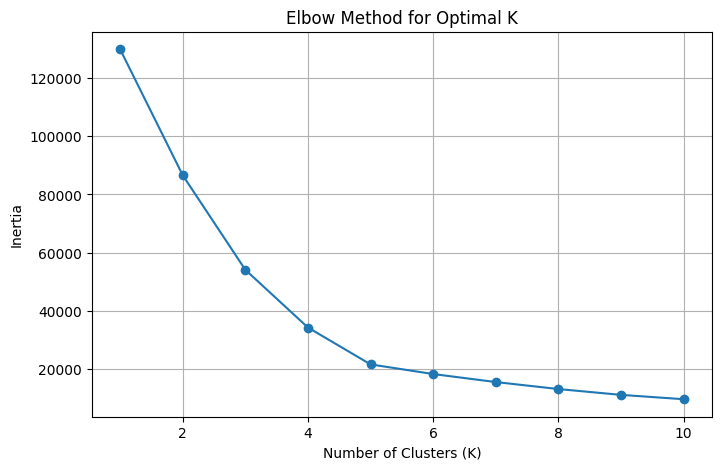


Cluster Counts:
Cluster
0    21664
1    21630
2        1
Name: count, dtype: int64

Cluster Centers:
    user_age  session_duration_sec  memory_usage_mb
0  46.562073         -1.289427e+22      1059.695542
1  46.271294          4.624051e+27      3091.499260
2  43.000000          2.000000e+39      3538.000000


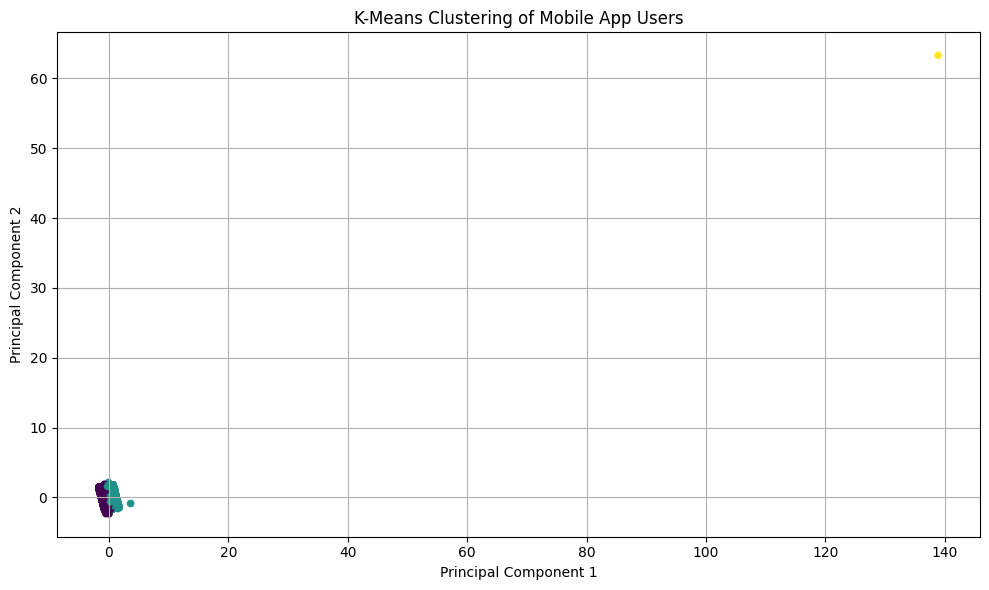

In [4]:
# ============================================
# K-MEANS CLUSTERING - MOBILE APP INTERACTIONS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------

df = pd.read_csv("mobile_app_interactions_expanded.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# --------------------------------------------
# 2. Convert required columns to numeric
# --------------------------------------------

df["user_age"] = pd.to_numeric(df["user_age"], errors="coerce")

df["session_duration_sec"] = pd.to_numeric(
    df["session_duration_sec"],
    errors="coerce"
)

df["memory_usage_mb"] = pd.to_numeric(
    df["memory_usage_mb"],
    errors="coerce"
)


# --------------------------------------------
# 3. Select features for K-Means
# --------------------------------------------

features = [
    "user_age",
    "session_duration_sec",
    "memory_usage_mb"
]

X = df[features]


# --------------------------------------------
# 4. Remove missing values and handle outliers
# --------------------------------------------

X = X.dropna()

# Cap extreme values to prevent distortion of scaling
# Based on typical app usage, session duration and memory usage have upper limits.
# These values are chosen heuristically and can be adjusted.
max_session_duration = 10000  # seconds (approx 2.7 hours)
max_memory_usage = 5000       # MB (approx 5 GB)

X["session_duration_sec"] = np.clip(X["session_duration_sec"], 0, max_session_duration)
X["memory_usage_mb"] = np.clip(X["memory_usage_mb"], 0, max_memory_usage)

print("Data used for clustering:", X.shape)
print("Descriptive statistics after outlier handling:")
print(X.describe())


# --------------------------------------------
# 5. Feature Scaling
# --------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# --------------------------------------------
# 6. Find suitable number of clusters
#    Using Elbow Method
# --------------------------------------------

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


# --------------------------------------------
# 7. Plot Elbow Graph
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.grid(True)

plt.show()


# --------------------------------------------
# 8. Apply K-Means
# --------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)


# --------------------------------------------
# 9. Add Cluster Labels
# --------------------------------------------

X["Cluster"] = clusters


# --------------------------------------------
# 10. Display Cluster Counts
# --------------------------------------------

print("\nCluster Counts:")

print(X["Cluster"].value_counts())


# --------------------------------------------
# 11. Display Cluster Centers
# --------------------------------------------

centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers = pd.DataFrame(
    centers,
    columns=features
)

print("\nCluster Centers:")

print(cluster_centers)


# --------------------------------------------
# 12. PCA for Visualization
# --------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


# --------------------------------------------
# 13. Plot K-Means Clusters
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clustering of Mobile App Users")

plt.grid(True)

plt.tight_layout()

plt.show()